# Kirkland Si[111]/Si[110] Convergent-Probe CBED

Simulate a silicon convergent-beam electron diffraction pattern at 100 keV and compare WPM, angular-spectrum multislice, and Fresnel multislice internally.

The cleaned default records a single crystal thickness near 1000 A, supports scattering angles to 300 mrad, and plots one CBED pattern image. Set `ZONE_AXIS = "111"` or `ZONE_AXIS = "110"` below.


In [168]:
%matplotlib widget

import os
import sys
from pathlib import Path
from time import perf_counter

# Set these before importing abTEM/CuPy/JAX in a fresh kernel.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", ".70")


def resolve_repo_root():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "notebooks").exists() and (base / "wide_angle_propagation").exists():
            return base
    return cwd


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import abtem
import ase.io
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from wide_angle_propagation.propagation_methods import (
    Propagator,
    angular_spectrum_propagation_kernel,
    electron_refractive_index,
    energy2wavelength,
    fresnel_propagation_kernel,
    wpm_step_adaptive,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

print(f"Repository root: {REPO_ROOT}")
print(f"CUDA_VISIBLE_DEVICES = {os.environ.get('CUDA_VISIBLE_DEVICES')}")


Repository root: /home/dl277493/Documents/Code/WideAnglePropagation
CUDA_VISIBLE_DEVICES = 0


## Experiment setup

The full run uses 100 keV electrons, an 8 mrad objective aperture, Cs = 3.3 mm, and Scherzer defocus. The target thickness is represented by the nearest integer number of repeated silicon unit cells along the selected zone axis.


In [ ]:
# --- Runtime controls -------------------------------------------------------
DEBUG_MODE = False
LOAD_EXISTING_RESULTS = False
RECOMPUTE_SIMULATION = True
SAVE_RESULTS_NPZ = True
SAVE_FIGURES = True

ZONE_AXIS = "111"  # Set to "111" or "110".
if ZONE_AXIS not in {"111", "110"}:
    raise ValueError(f"Unsupported ZONE_AXIS={ZONE_AXIS!r}; expected '111' or '110'.")

axis_tag = f"si{ZONE_AXIS}"
simulation_mode_label = "static crystal"
RESULTS_FILENAME = f"cbed_kirkland_{axis_tag}_100kev_300mrad_1000A.npz"
PATTERN_FIGURE_BASENAME = f"cbed_kirkland_{axis_tag}_pattern_300mrad_1000A"

# --- Kirkland Fig. 7.20-style optics ---------------------------------------
energy = 100e3
TARGET_THICKNESSES_A = np.array([1000.0], dtype=float)
PROBE_SEMIANGLE_MRAD = 8.0
CS_MM = 0.0
MAX_SCATTERING_ANGLE_MRAD = 300.0

# --- Numerical controls -----------------------------------------------------
# At 100 keV, 0.05 A sampling gives a Nyquist angle above 300 mrad.
POTENTIAL_SAMPLING_A = 0.05
SLICES_PER_CELL = 32
WPM_N_BINS = 16
WPM_POWER_SPACING = 2.0
RADIAL_BIN_WIDTH_MRAD = 0.5
CBED_LOG_VMIN = 1e-8

# The archived Si notebook used this lateral Si[111] supercell for Kirkland-like CBED.
FULL_LATERAL_REPEATS = (12, 7)
DEBUG_LATERAL_REPEATS = (4, 3)
DEBUG_TARGET_THICKNESSES_A = np.array([50.0], dtype=float)

if DEBUG_MODE:
    lateral_repeats = DEBUG_LATERAL_REPEATS
    target_thicknesses_A = DEBUG_TARGET_THICKNESSES_A.copy()
else:
    lateral_repeats = FULL_LATERAL_REPEATS
    target_thicknesses_A = TARGET_THICKNESSES_A.copy()

wavelength = float(energy2wavelength(energy))
cs_A = CS_MM * 1.0e7
scherzer_defocus_A = -1.2 * np.sqrt(cs_A * wavelength)

results_dir = REPO_ROOT / "notebooks" / "cbed" / "results"
results_path = results_dir / RESULTS_FILENAME
figures_dir = results_dir

print(f"Mode: {'debug' if DEBUG_MODE else 'full'}")
print(f"Zone axis: Si[{ZONE_AXIS}]")
print(f"Simulation mode: {simulation_mode_label}")
print(f"Energy: {energy / 1e3:.0f} keV, wavelength = {wavelength:.5f} A")
print(f"Probe aperture semi-angle: {PROBE_SEMIANGLE_MRAD:.1f} mrad")
print(f"Cs: {CS_MM:.2f} mm = {cs_A:.3e} A")
print(f"Scherzer defocus: {scherzer_defocus_A:.1f} A ({scherzer_defocus_A / 10:.1f} nm)")
print(f"Maximum scattering angle: {MAX_SCATTERING_ANGLE_MRAD:.0f} mrad")
print(f"Target thicknesses: {target_thicknesses_A} A")
print(f"Lateral repeats: {lateral_repeats[0]} x {lateral_repeats[1]}")
print(f"Result cache: {results_path}")



Mode: full
Zone axis: Si[111]
Simulation mode: static crystal
Energy: 100 keV, wavelength = 0.03701 A
Probe aperture semi-angle: 8.0 mrad
Cs: 0.00 mm = 0.000e+00 A
Scherzer defocus: -0.0 A (-0.0 nm)
Maximum scattering angle: 300 mrad
Target thicknesses: [1000.] A
Lateral repeats: 12 x 7
Result cache: /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_kirkland_si111_100kev_300mrad_1000A.npz


## Crystal setup

Construct an orthogonal silicon unit cell from `notebooks/data/Si.cif`. `Si[111]` uses the archived rotation recipe; `Si[110]` uses a rotated bulk-periodic cell so the beam direction remains periodic.



In [170]:
si_cif_path = REPO_ROOT / "notebooks" / "data" / "Si.cif"
if not si_cif_path.exists():
    raise FileNotFoundError(f"Missing Si CIF file: {si_cif_path}")

silicon = ase.io.read(si_cif_path)
if ZONE_AXIS == "111":
    zone_axis_label = "Si[111]"
    silicon_oriented = silicon.copy()
    silicon_oriented.rotate((0, 0, 1), (1, 1, 1), rotate_cell=True)
    silicon_oriented.rotate(45, "z", rotate_cell=True)
elif ZONE_AXIS == "110":
    zone_axis_label = "Si[110]"
    silicon_oriented = silicon.copy()
    silicon_oriented.rotate((0, 0, 1), (1, 1, 0), rotate_cell=True)
    silicon_oriented.rotate(45, "z", rotate_cell=True)
else:
    raise AssertionError(f"Unhandled ZONE_AXIS={ZONE_AXIS!r}")

unit_cell = abtem.orthogonalize_cell(silicon_oriented)
unit_cell.pbc = [True, True, True]
unit_cell.wrap()

nx_rep, ny_rep = lateral_repeats
unit_supercell = unit_cell * (nx_rep, ny_rep, 1)
unit_supercell.pbc = [True, True, True]

cell_lengths_A = np.array(unit_cell.cell.lengths(), dtype=float)
cell_thickness_A = float(unit_cell.cell[2, 2])
dz_test_A = cell_thickness_A / SLICES_PER_CELL
cell_repeats = np.maximum(1, np.rint(target_thicknesses_A / cell_thickness_A).astype(int))
actual_thicknesses_A = cell_repeats * cell_thickness_A
max_cell_repeats = int(cell_repeats.max())

print(f"Orthogonal {zone_axis_label} unit cell lengths: {cell_lengths_A} A")
print(f"{zone_axis_label} repeat thickness: {cell_thickness_A:.4f} A")
print(f"Slices per repeat: {SLICES_PER_CELL}, dz = {dz_test_A:.4f} A")
print("Thickness mapping:")
for target, repeat, actual in zip(target_thicknesses_A, cell_repeats, actual_thicknesses_A):
    print(f"  target {target:7.1f} A -> {repeat:4d} repeats -> actual {actual:8.2f} A")
print(f"One-cell lateral supercell atoms: {len(unit_supercell)}")
print(f"One-cell lateral field of view: {unit_supercell.cell.lengths()[0]:.2f} x {unit_supercell.cell.lengths()[1]:.2f} A")


Orthogonal Si[111] unit cell lengths: [ 7.69855772 13.33429312  9.42876909] A
Si[111] repeat thickness: 9.4288 A
Slices per repeat: 32, dz = 0.2946 A
Thickness mapping:
  target  1000.0 A ->  106 repeats -> actual   999.45 A
One-cell lateral supercell atoms: 4032
One-cell lateral field of view: 92.38 x 93.34 A


## Simulation helpers

These helpers avoid storing every per-slice wavefront during the thick-specimen run. Only the exit wave after each repeated unit cell is retained, and CBED patterns are recorded at the requested thickness.


In [171]:
METHOD_NAMES = ["WPM", "Angular Spectrum", "Fresnel MS"]
METHOD_LABELS = {
    "WPM": "WPM",
    "Angular Spectrum": "AS-MS",
    "Fresnel MS": "F-MS",
}
METHOD_COLORS = {
    "WPM": "C2",
    "Angular Spectrum": "C1",
    "Fresnel MS": "C0",
}
METHOD_LINESTYLES = {
    "WPM": "-",
    "Angular Spectrum": "--",
    "Fresnel MS": ":",
}


def method_key(method_name):
    return method_name.lower().replace(" ", "_").replace("-", "_")


def assert_scattering_support(sampling_A, wavelength_A, max_angle_mrad):
    max_sampling_A = max(float(sampling_A[0]), float(sampling_A[1]))
    nyquist_mrad = 1e3 * np.arcsin(np.clip(wavelength_A / (2.0 * max_sampling_A), 0.0, 1.0))
    print(f"Grid sampling: ({sampling_A[0]:.5f}, {sampling_A[1]:.5f}) A")
    print(f"Nyquist scattering angle: {nyquist_mrad:.1f} mrad")
    if nyquist_mrad < max_angle_mrad:
        raise ValueError(
            f"Grid only supports {nyquist_mrad:.1f} mrad, below requested "
            f"{max_angle_mrad:.1f} mrad. Reduce POTENTIAL_SAMPLING_A."
        )
    return nyquist_mrad


def build_potential_array(atoms, *, gpts=None, announce_label=None):
    potential_kwargs = {
        "slice_thickness": dz_test_A,
        "projection": "finite",
        "parametrization": "lobato",
    }
    if gpts is None:
        potential_kwargs["sampling"] = POTENTIAL_SAMPLING_A
    else:
        potential_kwargs["gpts"] = gpts

    potential_abtem = abtem.Potential(atoms, **potential_kwargs)
    gpts_local = tuple(int(v) for v in potential_abtem.gpts)
    sampling_local = tuple(float(v) for v in potential_abtem.sampling)
    built = cupy.asnumpy(potential_abtem.build(lazy=False).array)
    pot_local = jnp.array(built / dz_test_A, dtype=jnp.float64)
    del potential_abtem, built
    cupy.get_default_memory_pool().free_all_blocks()

    if announce_label is not None:
        print(f"Built potential for {announce_label}: shape={pot_local.shape}, grid={gpts_local}")
    if pot_local.shape[0] != SLICES_PER_CELL:
        print(
            "Warning: built potential has "
            f"{pot_local.shape[0]} slices, expected {SLICES_PER_CELL}. "
            "Using the configured dz for propagation."
        )
    return pot_local, gpts_local, sampling_local


def build_reference_potential_and_kernels():
    print(f"Building reference one-cell {zone_axis_label} potential...")
    pot_cell_local, gpts_local, sampling_local = build_potential_array(unit_supercell)
    fk_local = jnp.array(
        fresnel_propagation_kernel(*gpts_local, sampling_local, z=dz_test_A, energy=energy)
    )
    ak_local = jnp.array(
        angular_spectrum_propagation_kernel(*gpts_local, sampling_local, z=dz_test_A, energy=energy)
    )
    print(f"Potential shape: {pot_cell_local.shape}")
    print(f"Grid: {gpts_local}")
    assert_scattering_support(sampling_local, wavelength, MAX_SCATTERING_ANGLE_MRAD)
    return pot_cell_local, fk_local, ak_local, gpts_local, sampling_local



def make_kirkland_probe(ny, nx, sampling_A, wavelength_A, semiangle_mrad, defocus_A, cs_A):
    samp_y, samp_x = sampling_A
    fy = np.fft.fftfreq(ny, d=samp_y)
    fx = np.fft.fftfreq(nx, d=samp_x)
    fx_grid, fy_grid = np.meshgrid(fx, fy)
    spatial_frequency = np.sqrt(fx_grid**2 + fy_grid**2)
    alpha = np.arcsin(np.clip(wavelength_A * spatial_frequency, 0.0, 1.0))

    aperture = alpha <= semiangle_mrad * 1e-3
    if not np.any(aperture):
        raise ValueError(f"No aperture pixels for {semiangle_mrad} mrad probe")

    aberration_length_A = 0.5 * defocus_A * alpha**2 + 0.25 * cs_A * alpha**4
    aberration_phase = np.exp(-1j * (2.0 * np.pi / wavelength_A) * aberration_length_A)
    probe_fft = aperture.astype(np.complex128) * aberration_phase
    probe_fft /= np.linalg.norm(probe_fft)

    # The FFT grid is unshifted; fftshift centers the real-space probe in the array.
    probe = np.fft.fftshift(np.fft.ifft2(probe_fft))
    return jnp.array(probe, dtype=jnp.complex128)


def simulate_fresnel_as_exit_only(potential, wave, propagation_kernel, slice_thickness_A, energy_eV):
    wavelength_A = energy2wavelength(energy_eV)
    wavefront = wave
    for i in range(potential.shape[0]):
        n_map = electron_refractive_index(potential[i], energy_eV)
        phase_shift = jnp.exp(1j * 2.0 * jnp.pi * (n_map - 1.0) * slice_thickness_A / wavelength_A)
        wavefront = Propagator(wavefront * phase_shift, propagation_kernel)
    return wavefront


def simulate_wpm_exit_only(
    potential,
    wave,
    slice_thickness_A,
    energy_eV,
    sampling_A,
    n_bins=WPM_N_BINS,
    power_spacing=WPM_POWER_SPACING,
):
    wavefront = wave
    for i in range(potential.shape[0]):
        n_map = electron_refractive_index(potential[i], energy_eV)
        wavefront, _, _, _ = wpm_step_adaptive(
            wavefront,
            n_map,
            slice_thickness_A,
            energy_eV,
            sampling_A,
            n_bins=n_bins,
            power_spacing=power_spacing,
        )
    return wavefront


def block_until_ready(value):
    return jax.block_until_ready(value)


def diffraction_pattern(exit_wave):
    wave = np.asarray(exit_wave)
    return np.abs(np.fft.fftshift(np.fft.fft2(wave))) ** 2


def diffraction_angle_axes_mrad(ny, nx, sampling_A, wavelength_A):
    samp_y, samp_x = sampling_A
    fy = np.fft.fftshift(np.fft.fftfreq(ny, d=samp_y))
    fx = np.fft.fftshift(np.fft.fftfreq(nx, d=samp_x))
    theta_y = 1e3 * np.arcsin(np.clip(wavelength_A * fy, -1.0, 1.0))
    theta_x = 1e3 * np.arcsin(np.clip(wavelength_A * fx, -1.0, 1.0))
    return theta_y, theta_x


def angle_crop_slices(theta_y, theta_x, cutoff_mrad):
    y_idx = np.where(np.abs(theta_y) <= cutoff_mrad)[0]
    x_idx = np.where(np.abs(theta_x) <= cutoff_mrad)[0]
    if y_idx.size == 0 or x_idx.size == 0:
        raise ValueError(f"No pixels inside +/- {cutoff_mrad} mrad crop")
    return slice(y_idx[0], y_idx[-1] + 1), slice(x_idx[0], x_idx[-1] + 1)


def radial_integrated_profiles(patterns_by_method, theta_y, theta_x, max_angle_mrad, bin_width_mrad):
    theta_x_grid, theta_y_grid = np.meshgrid(theta_x, theta_y)
    radius = np.sqrt(theta_x_grid**2 + theta_y_grid**2)
    valid = radius <= max_angle_mrad
    bin_edges = np.arange(0.0, max_angle_mrad + bin_width_mrad, bin_width_mrad)
    if bin_edges[-1] < max_angle_mrad:
        bin_edges = np.append(bin_edges, max_angle_mrad)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    radial_sums = {}
    radial_profiles = {}
    for method, stack in patterns_by_method.items():
        method_sums = []
        method_profiles = []
        for pattern in stack:
            annular_sum, _ = np.histogram(radius[valid], bins=bin_edges, weights=np.asarray(pattern)[valid])
            annular_sum = annular_sum.astype(np.float64)
            total = float(annular_sum.sum())
            profile = annular_sum / total if total > 0.0 else annular_sum
            method_sums.append(annular_sum)
            method_profiles.append(profile)
        radial_sums[method] = np.stack(method_sums)
        radial_profiles[method] = np.stack(method_profiles)
    return bin_edges, bin_centers, radial_sums, radial_profiles


def metadata_dict(gpts, sampling_A, nyquist_mrad):
    return {
        "description": "Kirkland Fig. 7.20 silicon CBED comparison",
        "energy_eV": float(energy),
        "wavelength_A": float(wavelength),
        "probe_semiangle_mrad": float(PROBE_SEMIANGLE_MRAD),
        "Cs_mm": float(CS_MM),
        "Cs_A": float(cs_A),
        "defocus_A": float(scherzer_defocus_A),
        "max_scattering_angle_mrad": float(MAX_SCATTERING_ANGLE_MRAD),
        "potential_sampling_requested_A": float(POTENTIAL_SAMPLING_A),
        "sampling_A": tuple(float(v) for v in sampling_A),
        "gpts": tuple(int(v) for v in gpts),
        "nyquist_angle_mrad": float(nyquist_mrad),
        "slices_per_cell": int(SLICES_PER_CELL),
        "dz_A": float(dz_test_A),
        "cell_thickness_A": float(cell_thickness_A),
        "lateral_repeats": tuple(int(v) for v in lateral_repeats),
        "target_thicknesses_A": tuple(float(v) for v in target_thicknesses_A),
        "actual_thicknesses_A": tuple(float(v) for v in actual_thicknesses_A),
        "cell_repeats": tuple(int(v) for v in cell_repeats),
        "radial_bin_width_mrad": float(RADIAL_BIN_WIDTH_MRAD),
        "zone_axis": str(ZONE_AXIS),
        "zone_axis_label": str(zone_axis_label),
        "debug_mode": bool(DEBUG_MODE),
    }


def save_results(path, cbed_results):
    arrays = {
        "method_names": np.array(cbed_results["method_names"], dtype=object),
        "target_thicknesses_A": np.asarray(cbed_results["target_thicknesses_A"], dtype=float),
        "actual_thicknesses_A": np.asarray(cbed_results["actual_thicknesses_A"], dtype=float),
        "cell_repeats": np.asarray(cbed_results["cell_repeats"], dtype=int),
        "gpts": np.asarray(cbed_results["gpts"], dtype=int),
        "sampling_A": np.asarray(cbed_results["sampling_A"], dtype=float),
        "theta_y_mrad": np.asarray(cbed_results["theta_y_mrad"], dtype=float),
        "theta_x_mrad": np.asarray(cbed_results["theta_x_mrad"], dtype=float),
        "radial_bin_edges_mrad": np.asarray(cbed_results["radial_bin_edges_mrad"], dtype=float),
        "radial_bin_centers_mrad": np.asarray(cbed_results["radial_bin_centers_mrad"], dtype=float),
        "metadata": np.array([cbed_results["metadata"]], dtype=object),
    }
    for method in cbed_results["method_names"]:
        key = method_key(method)
        arrays[f"{key}_patterns"] = np.asarray(cbed_results["patterns"][method], dtype=np.float32)
        arrays[f"{key}_radial_sums"] = np.asarray(cbed_results["radial_sums"][method], dtype=np.float64)
        arrays[f"{key}_radial_profiles"] = np.asarray(cbed_results["radial_profiles"][method], dtype=np.float64)
        arrays[f"{key}_runtime_at_targets_s"] = np.asarray(cbed_results["runtime_at_targets_s"][method], dtype=float)
        arrays[f"{key}_cell_runtime_s"] = np.asarray(cbed_results["cell_runtime_s"][method], dtype=float)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, **arrays)
    print(f"Saved compact results -> {path}")


def load_results(path):
    with np.load(path, allow_pickle=True) as data:
        loaded_methods = [str(v) for v in data["method_names"]]
        loaded = {
            "method_names": loaded_methods,
            "target_thicknesses_A": data["target_thicknesses_A"].astype(float),
            "actual_thicknesses_A": data["actual_thicknesses_A"].astype(float),
            "cell_repeats": data["cell_repeats"].astype(int),
            "gpts": tuple(int(v) for v in data["gpts"]),
            "sampling_A": tuple(float(v) for v in data["sampling_A"]),
            "theta_y_mrad": data["theta_y_mrad"].astype(float),
            "theta_x_mrad": data["theta_x_mrad"].astype(float),
            "radial_bin_edges_mrad": data["radial_bin_edges_mrad"].astype(float),
            "radial_bin_centers_mrad": data["radial_bin_centers_mrad"].astype(float),
            "metadata": dict(data["metadata"][0]),
            "patterns": {},
            "radial_sums": {},
            "radial_profiles": {},
            "runtime_at_targets_s": {},
            "cell_runtime_s": {},
        }
        for method in loaded_methods:
            key = method_key(method)
            loaded["patterns"][method] = data[f"{key}_patterns"].copy()
            loaded["radial_sums"][method] = data[f"{key}_radial_sums"].copy()
            loaded["radial_profiles"][method] = data[f"{key}_radial_profiles"].copy()
            loaded["runtime_at_targets_s"][method] = data[f"{key}_runtime_at_targets_s"].copy()
            loaded["cell_runtime_s"][method] = data[f"{key}_cell_runtime_s"].copy()
    print(f"Loaded compact results -> {path}")
    return loaded




## Load or run CBED simulation

The simulation reuses one static repeated-cell potential for efficiency and records the CBED pattern at the requested thickness.


In [172]:
should_load = LOAD_EXISTING_RESULTS and results_path.exists() and not RECOMPUTE_SIMULATION

if should_load:
    cbed_results = load_results(results_path)
    gpts = tuple(cbed_results["gpts"])
    sampling = tuple(cbed_results["sampling_A"])
    theta_y_mrad = cbed_results["theta_y_mrad"]
    theta_x_mrad = cbed_results["theta_x_mrad"]
    assert_scattering_support(sampling, wavelength, MAX_SCATTERING_ANGLE_MRAD)
else:
    pot_cell, fk, ak, gpts, sampling = build_reference_potential_and_kernels()
    ny_g, nx_g = gpts
    theta_y_mrad, theta_x_mrad = diffraction_angle_axes_mrad(ny_g, nx_g, sampling, wavelength)

    probe = make_kirkland_probe(
        ny_g,
        nx_g,
        sampling,
        wavelength,
        PROBE_SEMIANGLE_MRAD,
        scherzer_defocus_A,
        cs_A,
    )
    block_until_ready(probe)

    repeat_to_target_indices = {}
    for idx, repeat in enumerate(cell_repeats):
        repeat_to_target_indices.setdefault(int(repeat), []).append(idx)

    patterns = {
        method: np.zeros((len(cell_repeats), ny_g, nx_g), dtype=np.float64)
        for method in METHOD_NAMES
    }
    cell_runtime_s = {
        method: np.zeros(max_cell_repeats, dtype=float)
        for method in METHOD_NAMES
    }
    runtime_at_targets_s = {
        method: np.zeros(len(cell_repeats), dtype=float)
        for method in METHOD_NAMES
    }

    waves = {method: probe for method in METHOD_NAMES}
    cumulative_runtime_s = {method: 0.0 for method in METHOD_NAMES}
    print(f"Propagating {max_cell_repeats} {zone_axis_label} repeats through {METHOD_NAMES}...")

    for cell_idx in range(1, max_cell_repeats + 1):
        if cell_idx == 1 or cell_idx in repeat_to_target_indices or cell_idx % 10 == 0 or cell_idx == max_cell_repeats:
            print(f"  repeat {cell_idx:4d}/{max_cell_repeats} ({cell_idx * cell_thickness_A:8.2f} A)")

        for method in METHOD_NAMES:
            t0 = perf_counter()
            if method == "WPM":
                waves[method] = simulate_wpm_exit_only(
                    pot_cell,
                    waves[method],
                    dz_test_A,
                    energy,
                    sampling,
                    n_bins=WPM_N_BINS,
                    power_spacing=WPM_POWER_SPACING,
                )
            elif method == "Angular Spectrum":
                waves[method] = simulate_fresnel_as_exit_only(pot_cell, waves[method], ak, dz_test_A, energy)
            elif method == "Fresnel MS":
                waves[method] = simulate_fresnel_as_exit_only(pot_cell, waves[method], fk, dz_test_A, energy)
            else:
                raise KeyError(method)
            block_until_ready(waves[method])
            elapsed = perf_counter() - t0
            cell_runtime_s[method][cell_idx - 1] = elapsed
            cumulative_runtime_s[method] += elapsed

        if cell_idx in repeat_to_target_indices:
            for target_idx in repeat_to_target_indices[cell_idx]:
                for method in METHOD_NAMES:
                    patterns[method][target_idx] = diffraction_pattern(waves[method]).astype(np.float64)
                    runtime_at_targets_s[method][target_idx] = cumulative_runtime_s[method]

    patterns = {method: stack.astype(np.float32) for method, stack in patterns.items()}
    radial_bin_edges_mrad, radial_bin_centers_mrad, radial_sums, radial_profiles = radial_integrated_profiles(
        patterns,
        theta_y_mrad,
        theta_x_mrad,
        MAX_SCATTERING_ANGLE_MRAD,
        RADIAL_BIN_WIDTH_MRAD,
    )
    nyquist_mrad = assert_scattering_support(sampling, wavelength, MAX_SCATTERING_ANGLE_MRAD)

    cbed_results = {
        "method_names": METHOD_NAMES,
        "target_thicknesses_A": target_thicknesses_A.copy(),
        "actual_thicknesses_A": actual_thicknesses_A.copy(),
        "cell_repeats": cell_repeats.copy(),
        "gpts": gpts,
        "sampling_A": sampling,
        "theta_y_mrad": theta_y_mrad,
        "theta_x_mrad": theta_x_mrad,
        "radial_bin_edges_mrad": radial_bin_edges_mrad,
        "radial_bin_centers_mrad": radial_bin_centers_mrad,
        "patterns": patterns,
        "radial_sums": radial_sums,
        "radial_profiles": radial_profiles,
        "runtime_at_targets_s": runtime_at_targets_s,
        "cell_runtime_s": cell_runtime_s,
        "metadata": metadata_dict(gpts, sampling, nyquist_mrad),
    }

    if SAVE_RESULTS_NPZ:
        save_results(results_path, cbed_results)

    del fk, ak, pot_cell
    cupy.get_default_memory_pool().free_all_blocks()

print("Available result thicknesses:")
for target, repeat, actual in zip(
    cbed_results["target_thicknesses_A"],
    cbed_results["cell_repeats"],
    cbed_results["actual_thicknesses_A"],
):
    print(f"  target {target:7.1f} A -> {repeat:4d} repeats -> actual {actual:8.2f} A")

print("Timing at final recorded thickness:")
for method in cbed_results["method_names"]:
    print(f"  {METHOD_LABELS.get(method, method):<8s} {cbed_results['runtime_at_targets_s'][method][-1]:10.2f} s")



Building reference one-cell Si[111] potential...
Potential shape: (32, 1848, 1867)
Grid: (1848, 1867)
Grid sampling: (0.04999, 0.04999) A
Nyquist scattering angle: 379.2 mrad
Propagating 106 Si[111] repeats through ['WPM', 'Angular Spectrum', 'Fresnel MS']...
  repeat    1/106 (    9.43 A)
  repeat   10/106 (   94.29 A)
  repeat   20/106 (  188.58 A)
  repeat   30/106 (  282.86 A)
  repeat   40/106 (  377.15 A)
  repeat   50/106 (  471.44 A)
  repeat   60/106 (  565.73 A)
  repeat   70/106 (  660.01 A)
  repeat   80/106 (  754.30 A)
  repeat   90/106 (  848.59 A)
  repeat  100/106 (  942.88 A)
  repeat  106/106 (  999.45 A)
Grid sampling: (0.04999, 0.04999) A
Nyquist scattering angle: 379.2 mrad
Saved compact results -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_kirkland_si111_100kev_300mrad_1000A.npz
Available result thicknesses:
  target  1000.0 A ->  106 repeats -> actual   999.45 A
Timing at final recorded thickness:
  WPM          151.79 s
  AS-

## Validate cached arrays

This is a lightweight check that the stored CBED patterns and radial profiles are finite and have the expected method/thickness dimensions.



In [173]:
def validate_cbed_results(results):
    n_thicknesses = len(results["actual_thicknesses_A"])
    for method in results["method_names"]:
        pattern_stack = results["patterns"][method]
        radial_stack = results["radial_profiles"][method]
        if pattern_stack.shape[0] != n_thicknesses:
            raise ValueError(f"{method}: expected {n_thicknesses} patterns, got {pattern_stack.shape[0]}")
        if radial_stack.shape[0] != n_thicknesses:
            raise ValueError(f"{method}: expected {n_thicknesses} radial profiles, got {radial_stack.shape[0]}")
        if not np.all(np.isfinite(pattern_stack)):
            raise ValueError(f"{method}: non-finite CBED pattern values")
        if not np.all(np.isfinite(radial_stack)):
            raise ValueError(f"{method}: non-finite radial profile values")
    print("Validation passed: finite CBED patterns and radial profiles for all methods/thicknesses.")


validate_cbed_results(cbed_results)


Validation passed: finite CBED patterns and radial profiles for all methods/thicknesses.


## CBED pattern

Plot one CBED pattern at the largest recorded thickness, cropped to the configured scattering-angle limit.


Saved figure -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_kirkland_si111_pattern_300mrad_1000A.png
Saved figure -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_kirkland_si111_pattern_300mrad_1000A.pdf


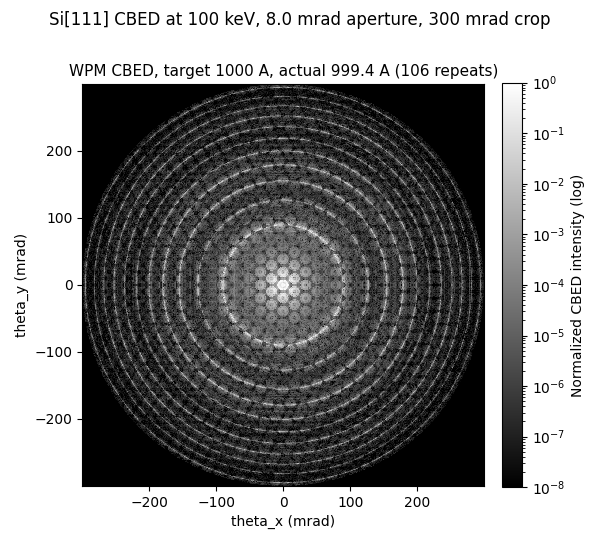

In [174]:
def masked_angle_crop(pattern, theta_y, theta_x, cutoff_mrad):
    y_slice, x_slice = angle_crop_slices(theta_y, theta_x, cutoff_mrad)
    crop = np.asarray(pattern)[y_slice, x_slice].astype(np.float64)
    tx_grid, ty_grid = np.meshgrid(theta_x[x_slice], theta_y[y_slice])
    radius = np.sqrt(tx_grid**2 + ty_grid**2)
    crop = np.where(radius <= cutoff_mrad, crop, np.nan)
    extent = [theta_x[x_slice.start], theta_x[x_slice.stop - 1], theta_y[y_slice.start], theta_y[y_slice.stop - 1]]
    return crop, extent


PLOT_METHOD = "WPM"
if PLOT_METHOD not in cbed_results["method_names"]:
    PLOT_METHOD = cbed_results["method_names"][0]

idx = int(np.argmax(cbed_results["actual_thicknesses_A"]))
target_A = cbed_results["target_thicknesses_A"][idx]
actual_A = cbed_results["actual_thicknesses_A"][idx]
repeat = int(cbed_results["cell_repeats"][idx])

crop, extent = masked_angle_crop(
    cbed_results["patterns"][PLOT_METHOD][idx],
    cbed_results["theta_y_mrad"],
    cbed_results["theta_x_mrad"],
    MAX_SCATTERING_ANGLE_MRAD,
)
finite = crop[np.isfinite(crop)]
if finite.size == 0 or float(finite.max()) <= 0.0:
    raise ValueError("CBED pattern has no positive intensity inside the plotting aperture")

display = crop / float(finite.max())
display = np.where(np.isfinite(display), np.maximum(display, CBED_LOG_VMIN), np.nan)

cmap = plt.get_cmap("gray").copy()
cmap.set_bad("black")

fig, ax = plt.subplots(figsize=(6.0, 5.6))
im = ax.imshow(
    display,
    origin="lower",
    extent=extent,
    cmap=cmap,
    norm=LogNorm(vmin=CBED_LOG_VMIN, vmax=1.0),
    interpolation="nearest",
)
ax.set_title(
    f"{METHOD_LABELS.get(PLOT_METHOD, PLOT_METHOD)} CBED, target {target_A:.0f} A, "
    f"actual {actual_A:.1f} A ({repeat:d} repeats)",
    fontsize=11,
)
ax.set_xlabel("theta_x (mrad)")
ax.set_ylabel("theta_y (mrad)")
ax.set_aspect("equal")
fig.suptitle(
    f"{zone_axis_label} CBED at {energy / 1e3:.0f} keV, {PROBE_SEMIANGLE_MRAD:.1f} mrad aperture, "
    f"{MAX_SCATTERING_ANGLE_MRAD:.0f} mrad crop",
    fontsize=12,
)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Normalized CBED intensity (log)")
fig.tight_layout()

if SAVE_FIGURES:
    figures_dir.mkdir(parents=True, exist_ok=True)
    png_path = figures_dir / f"{PATTERN_FIGURE_BASENAME}.png"
    pdf_path = figures_dir / f"{PATTERN_FIGURE_BASENAME}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved figure -> {png_path}")
    print(f"Saved figure -> {pdf_path}")

plt.show()



## Radially integrated intensity with peak finding

Radial profiles interpolated to a fine grid, with `scipy.signal.find_peaks` detecting Bragg rings on the log-transformed profile. Only the thickest specimen is shown.

WPM     :  13 peaks found
AS-MS   :  13 peaks found
F-MS    :  13 peaks found


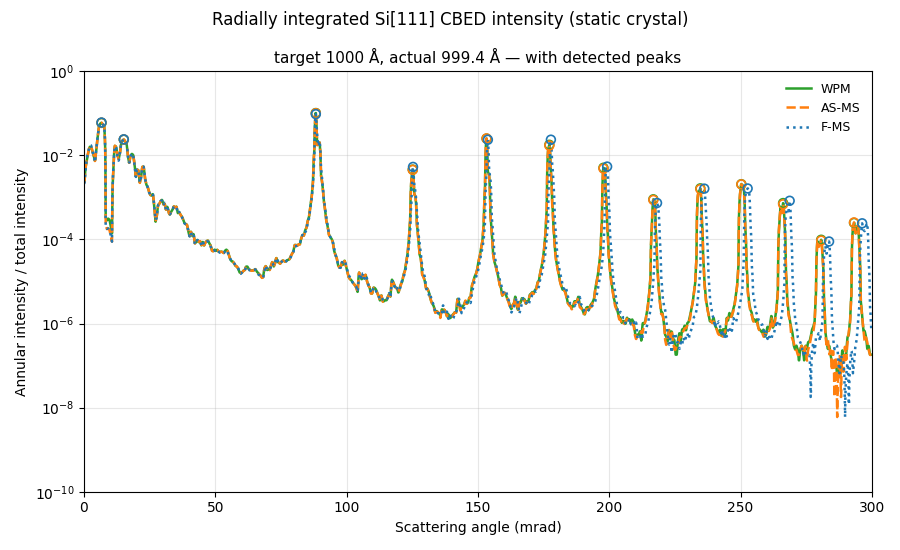

In [175]:
centers_raw = cbed_results["radial_bin_centers_mrad"]

# Interpolate onto a finer radial grid for smoother curves
FINE_BIN_WIDTH_MRAD = 0.1
centers = np.arange(0.0, centers_raw[-1] + FINE_BIN_WIDTH_MRAD, FINE_BIN_WIDTH_MRAD)

def resample_profile(profile_raw):
    """Linearly interpolate a radial profile onto the finer centers grid."""
    return np.interp(centers, centers_raw, np.asarray(profile_raw, dtype=np.float64))

idx = len(cbed_results["actual_thicknesses_A"]) - 1
target_A = cbed_results["target_thicknesses_A"][idx]
actual_A = cbed_results["actual_thicknesses_A"][idx]

fig, ax = plt.subplots(figsize=(9, 5.5))

# Peak-finding parameters
PEAK_MIN_ANGLE_MRAD = 5.0
PEAK_MAX_ANGLE_MRAD = 300.0
PEAK_PROMINENCE = 2   # in log10 units
PEAK_MIN_SPACING_MRAD = 4.0

dtheta = float(np.mean(np.diff(centers)))
min_peak_distance_bins = max(1, int(round(PEAK_MIN_SPACING_MRAD / dtheta)))
angle_mask = (centers >= PEAK_MIN_ANGLE_MRAD) & (centers <= PEAK_MAX_ANGLE_MRAD)

from scipy.signal import find_peaks

for method in method_plot_order:
    profile = resample_profile(cbed_results["radial_profiles"][method][idx])
    ax.semilogy(
        centers,
        np.maximum(profile, 1e-18),
        color=METHOD_COLORS.get(method, None),
        linestyle=METHOD_LINESTYLES.get(method, "-"),
        linewidth=1.8,
        label=METHOD_LABELS.get(method, method),
    )

    # Peak finding on log-transformed profile
    log_profile = np.log10(np.maximum(profile, 1e-18))
    masked = np.where(angle_mask, log_profile, -np.inf)
    peaks, props = find_peaks(
        masked, prominence=PEAK_PROMINENCE, distance=min_peak_distance_bins
    )
    print(f"{METHOD_LABELS.get(method, method):<8s}: {len(peaks):3d} peaks found")

    if len(peaks) > 0:
        ax.scatter(
            centers[peaks], profile[peaks],
            marker="o", s=40, facecolors="none",
            edgecolors=METHOD_COLORS.get(method, None),
            linewidths=1.2, zorder=5,
        )

ax.set_title(f"target {target_A:.0f} Å, actual {actual_A:.1f} Å — with detected peaks", fontsize=11)
ax.set_xlim(0.0, 300.0)
ax.set_ylim(1e-10, 1.0)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Scattering angle (mrad)")
ax.set_ylabel("Annular intensity / total intensity")
ax.legend(loc="best", frameon=False, fontsize=9)
fig.suptitle(f"Radially integrated {zone_axis_label} CBED intensity ({simulation_mode_label})", fontsize=12)
fig.tight_layout()
plt.show()

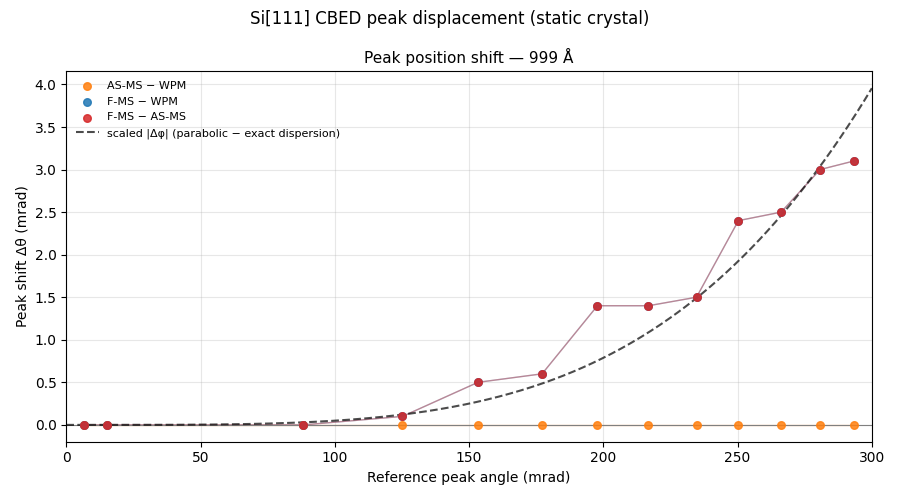

In [176]:
# --- Peak shift comparison: Δθ vs reference peak angle ------------------------
# Match peaks between method pairs by nearest-neighbour and plot the shift.

MAX_MATCH_DISTANCE_MRAD = 4.0

method_pairs = [
    ("Angular Spectrum", "WPM", "AS-MS − WPM", "C1"),
    ("Fresnel MS", "WPM", "F-MS − WPM", "C0"),
    ("Fresnel MS", "Angular Spectrum", "F-MS − AS-MS", "C3"),
]

# Recompute peaks (same parameters as above)
all_peaks = {}
for method in method_plot_order:
    profile = resample_profile(cbed_results["radial_profiles"][method][idx])
    log_profile = np.log10(np.maximum(profile, 1e-18))
    masked = np.where(angle_mask, log_profile, -np.inf)
    peaks, _ = find_peaks(masked, prominence=PEAK_PROMINENCE, distance=min_peak_distance_bins)
    all_peaks[method] = centers[peaks]

fig, ax = plt.subplots(figsize=(9, 5))

fw_ref_angles = None
fw_shifts = None

for method_a, method_b, label, color in method_pairs:
    ref_peaks = all_peaks[method_b]
    cmp_peaks = all_peaks[method_a]

    shifts = []
    ref_angles = []
    for rp in ref_peaks:
        dists = np.abs(cmp_peaks - rp)
        j = np.argmin(dists)
        if dists[j] <= MAX_MATCH_DISTANCE_MRAD:
            ref_angles.append(rp)
            shifts.append(cmp_peaks[j] - rp)

    ref_angles = np.array(ref_angles)
    shifts = np.array(shifts)
    ax.scatter(ref_angles, shifts, s=30, color=color, label=label, alpha=0.85, zorder=4)
    if len(ref_angles) >= 2:
        ax.plot(ref_angles, shifts, color=color, linewidth=1.0, alpha=0.4)

    if method_a == "Fresnel MS" and method_b == "WPM":
        fw_ref_angles = ref_angles.copy()
        fw_shifts = shifts.copy()

ax.axhline(0.0, color="0.5", linewidth=0.8)
ax.set_xlim(0.0, 300.0)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Reference peak angle (mrad)")
ax.set_ylabel("Peak shift Δθ (mrad)")
ax.set_title(f"Peak position shift — {actual_A:.0f} Å", fontsize=11)

# --- Parabolic vs exact dispersion relation error --------------------------
def dispersion_phase_error(angle_mrad, thickness_A, wavelength_A):
    """Phase error from the parabolic (Fresnel) vs. exact spherical dispersion.

    The exact propagator accumulates phase (2πt/λ)·[√(1−x) − 1]
    where  x = λ²q² = sin²θ  for a plane wave at scattering angle θ.

    The Fresnel propagator replaces √(1−x) with its Taylor expansion
    √(1−x) ≈ 1 − x/2, giving  φ_parab = (2πt/λ)·(−x/2).

    This function returns |φ_parab − φ_exact|, i.e. the truncation error
    of the square-root series (which grows ∝ x² ∝ θ⁴ at small angles).
    """
    theta = 1e-3 * np.asarray(angle_mrad, dtype=np.float64)
    x = np.sin(theta) ** 2                     # x = λ²q², 0 ≤ x < 1
    prefactor = 2.0 * np.pi * thickness_A / wavelength_A

    # Exact spherical dispersion:  √(1−x) − 1
    phase_exact = prefactor * (np.sqrt(1.0 - x) - 1.0)

    # Parabolic (Fresnel) dispersion:  Taylor  √(1−x) ≈ 1 − x/2  →  −x/2
    phase_parabolic = prefactor * (-0.5 * x)

    return np.abs(phase_parabolic - phase_exact)

if fw_ref_angles is not None and len(fw_ref_angles) >= 2:
    fw_ref = np.array(fw_ref_angles)
    fw_shifts_abs = np.abs(np.array(fw_shifts))
    theory_at_peaks = dispersion_phase_error(fw_ref, actual_A, wavelength)
    fit_scale = np.dot(theory_at_peaks, fw_shifts_abs) / np.dot(theory_at_peaks, theory_at_peaks)
    theory_angle = np.linspace(0, 300, 500)
    ax.plot(theory_angle, fit_scale * dispersion_phase_error(theory_angle, actual_A, wavelength),
            "k--", linewidth=1.5, alpha=0.7, label="scaled |Δφ| (parabolic − exact dispersion)")

ax.legend(loc="best", frameon=False, fontsize=8)
fig.suptitle(f"{zone_axis_label} CBED peak displacement ({simulation_mode_label})", fontsize=12)
fig.tight_layout()
plt.show()

## Combined publication figure

Three-panel layout: CBED pattern (WPM), radially integrated profiles with detected peaks, and peak displacement with scaled Fresnel-vs-exact phase error curve.

Saved figure -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_kirkland_si111_combined_300mrad_999A.png
Saved figure -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_kirkland_si111_combined_300mrad_999A.pdf


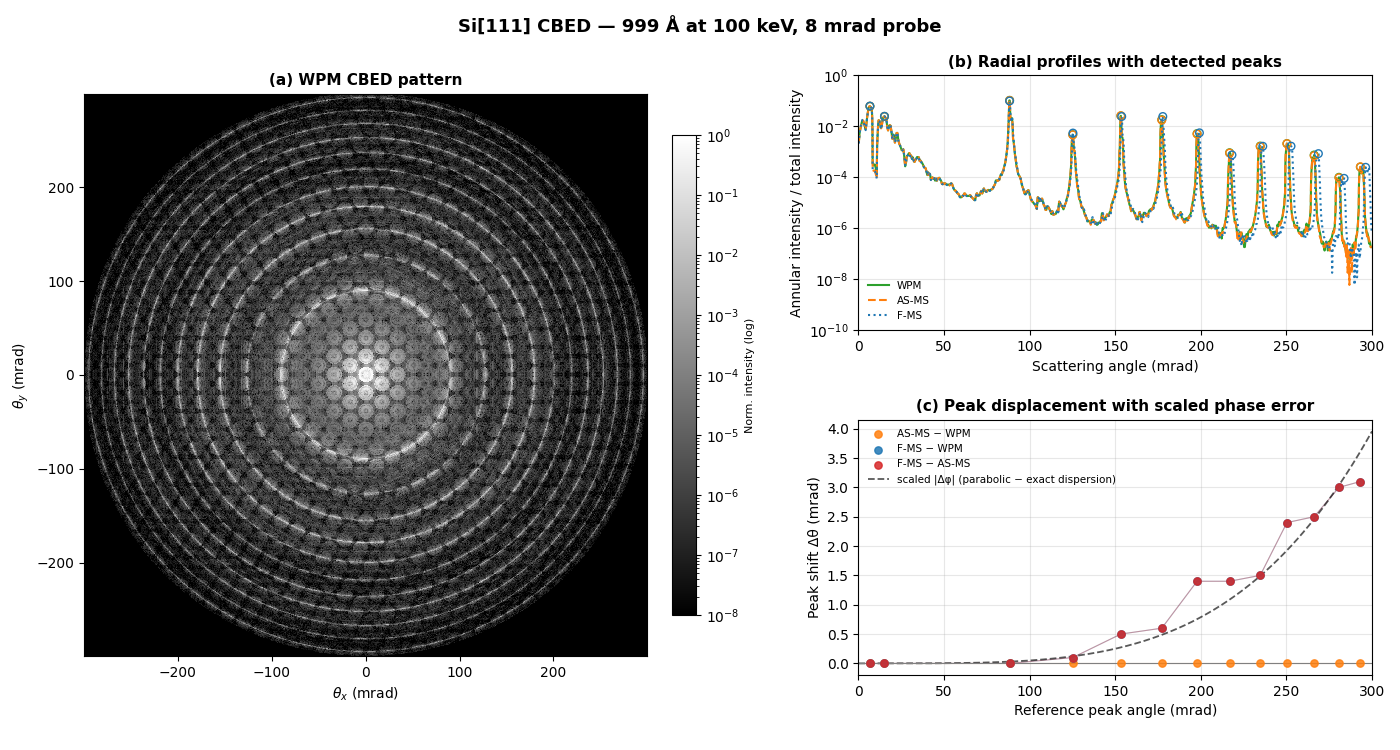

In [177]:
# --- Combined 3-panel publication figure ---------------------------------------
from matplotlib.gridspec import GridSpec

# (a) CBED pattern — WPM, thickest specimen ------------------------------------
crop, extent = masked_angle_crop(
    cbed_results["patterns"]["WPM"][idx],
    cbed_results["theta_y_mrad"],
    cbed_results["theta_x_mrad"],
    MAX_SCATTERING_ANGLE_MRAD,
)
finite = crop[np.isfinite(crop)]
cbed_img = crop / float(finite.max())
cbed_img = np.where(np.isfinite(cbed_img), np.maximum(cbed_img, CBED_LOG_VMIN), np.nan)

# (b) Radial profiles with peaks -----------------------------------------------
peak_data = {}
for method in method_plot_order:
    profile = resample_profile(cbed_results["radial_profiles"][method][idx])
    log_profile = np.log10(np.maximum(profile, 1e-18))
    masked = np.where(angle_mask, log_profile, -np.inf)
    peaks, _ = find_peaks(masked, prominence=PEAK_PROMINENCE, distance=min_peak_distance_bins)
    peak_data[method] = {"profile": profile, "peaks": peaks}

# (c) Peak shift data ----------------------------------------------------------
method_pairs_shift = [
    ("Angular Spectrum", "WPM", "AS-MS − WPM", "C1"),
    ("Fresnel MS", "WPM", "F-MS − WPM", "C0"),
    ("Fresnel MS", "Angular Spectrum", "F-MS − AS-MS", "C3"),
]
MAX_MATCH_DISTANCE_MRAD = 4.0

shift_data = {}
for method_a, method_b, label, color in method_pairs_shift:
    ref_peaks = all_peaks[method_b]
    cmp_peaks = all_peaks[method_a]
    ra, sh = [], []
    for rp in ref_peaks:
        dists = np.abs(cmp_peaks - rp)
        j = np.argmin(dists)
        if dists[j] <= MAX_MATCH_DISTANCE_MRAD:
            ra.append(rp)
            sh.append(cmp_peaks[j] - rp)
    shift_data[(method_a, method_b)] = {"ref_angles": np.array(ra), "shifts": np.array(sh),
                                         "label": label, "color": color}

# --- Build figure --------------------------------------------------------------
fig = plt.figure(figsize=(14, 7.5))
gs = GridSpec(2, 2, figure=fig, width_ratios=[1.2, 1.0], height_ratios=[1.0, 1.0],
              hspace=0.35, wspace=0.28,
              left=0.06, right=0.98, top=0.90, bottom=0.10)

# (a) CBED image — left column, spans both rows
ax_a = fig.add_subplot(gs[:, 0])
im_a = ax_a.imshow(cbed_img, origin="lower", extent=extent, cmap=cmap,
                    norm=LogNorm(vmin=CBED_LOG_VMIN, vmax=1.0), interpolation="nearest")
ax_a.set_title("(a) WPM CBED pattern", fontsize=11, fontweight="bold", pad=6)
ax_a.set_xlabel("$θ_x$ (mrad)")
ax_a.set_ylabel("$θ_y$ (mrad)")
ax_a.set_aspect("equal")
cbar_a = fig.colorbar(im_a, ax=ax_a, fraction=0.046, pad=0.04, shrink=0.80)
cbar_a.set_label("Norm. intensity (log)", fontsize=8)

# (b) Radial profiles + peaks — right top
ax_b = fig.add_subplot(gs[0, 1])
for method in method_plot_order:
    pd_m = peak_data[method]
    ax_b.semilogy(centers, np.maximum(pd_m["profile"], 1e-18),
                  color=METHOD_COLORS[method], linestyle=METHOD_LINESTYLES[method],
                  linewidth=1.5, label=METHOD_LABELS[method])
    if len(pd_m["peaks"]) > 0:
        ax_b.scatter(centers[pd_m["peaks"]], pd_m["profile"][pd_m["peaks"]],
                     marker="o", s=30, facecolors="none",
                     edgecolors=METHOD_COLORS[method], linewidths=1.0, zorder=5)
ax_b.set_title("(b) Radial profiles with detected peaks", fontsize=11, fontweight="bold")
ax_b.set_xlim(0.0, 300.0)
ax_b.set_ylim(1e-10, 1.0)
ax_b.grid(True, alpha=0.3)
ax_b.set_xlabel("Scattering angle (mrad)")
ax_b.set_ylabel("Annular intensity / total intensity")
ax_b.legend(loc="lower left", frameon=False, fontsize=7.5)

# (c) Peak shift + theory — right bottom
ax_c = fig.add_subplot(gs[1, 1])
fw_ra, fw_sh = None, None
for (method_a, method_b), sd in shift_data.items():
    ax_c.scatter(sd["ref_angles"], sd["shifts"], s=28, color=sd["color"],
                 label=sd["label"], alpha=0.85, zorder=4)
    if len(sd["ref_angles"]) >= 2:
        ax_c.plot(sd["ref_angles"], sd["shifts"], color=sd["color"],
                  linewidth=0.8, alpha=0.35)
    if method_a == "Fresnel MS" and method_b == "WPM":
        fw_ra, fw_sh = sd["ref_angles"], sd["shifts"]

if fw_ra is not None and len(fw_ra) >= 2:
    theory_at = dispersion_phase_error(np.array(fw_ra), actual_A, wavelength)
    fs = np.dot(theory_at, np.abs(np.array(fw_sh))) / np.dot(theory_at, theory_at)
    ta = np.linspace(0, 300, 500)
    ax_c.plot(ta, fs * dispersion_phase_error(ta, actual_A, wavelength),
              "k--", linewidth=1.3, alpha=0.65, label="scaled |Δφ| (parabolic − exact dispersion)")

ax_c.axhline(0.0, color="0.5", linewidth=0.8)
ax_c.set_title("(c) Peak displacement with scaled phase error", fontsize=11, fontweight="bold")
ax_c.set_xlim(0.0, 300.0)
ax_c.grid(True, alpha=0.3)
ax_c.set_xlabel("Reference peak angle (mrad)")
ax_c.set_ylabel("Peak shift Δθ (mrad)")
ax_c.legend(loc="best", frameon=False, fontsize=7.5)

fig.suptitle(
    f"{zone_axis_label} CBED — {actual_A:.0f} Å at {energy/1e3:.0f} keV, "
    f"{PROBE_SEMIANGLE_MRAD:.0f} mrad probe",
    fontsize=13, fontweight="bold",
)

COMBINED_FIGURE_BASENAME = f"cbed_kirkland_{axis_tag}_combined_300mrad_{actual_A:.0f}A"

if SAVE_FIGURES:
    figures_dir.mkdir(parents=True, exist_ok=True)
    png_path = figures_dir / f"{COMBINED_FIGURE_BASENAME}.png"
    pdf_path = figures_dir / f"{COMBINED_FIGURE_BASENAME}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved figure -> {png_path}")
    print(f"Saved figure -> {pdf_path}")

plt.show()